In [2]:
import importlib
import pandas as pd
import numpy as np
import pickle
import random

import globals
import utils

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)

seed = 42
random.seed(seed)
np.random.seed(seed)

In [3]:
importlib.reload(globals)
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Masters_Thesis\\utils.py'>

In [4]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [5]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))

X_tr, X_val, X_test, Y_tr, Y_val, Y_test = utils.train_val_test_split(X, Y_resh, wavelengths, verbose=True)

X shape: (500, 9)
Y shape: (500, 6, 4205)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (50, 9)
X_test shape: (50, 9)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)


#### Comparison between Methods

In [6]:
mre_single = {}
mae_single = {}
mre_sel = {}
mae_sel = {}
mre_nodimred = {}
mae_nodimred = {}

mre_to_plot = {}
mae_to_plot = {}

with (
    open("gp_saves/testing_results/single_kernel/mre_per_wvl_log.pkl", "rb") as f1,
    open("gp_saves/testing_results/single_kernel/mae_per_wvl.pkl", "rb") as f2,
    open("gp_saves/testing_results/kernel_selection/mre_per_wvl_log.pkl", "rb") as f3,
    open("gp_saves/testing_results/kernel_selection/mae_per_wvl.pkl", "rb") as f4,
    open("gp_saves/testing_results/nodimred/mre_per_wvl_log.pkl", "rb") as f5,
    open("gp_saves/testing_results/nodimred/mae_per_wvl.pkl", "rb") as f6,
    open("nn_saves/testing_results/mre_per_wvl_log.pkl", "rb") as f7,
    open("nn_saves/testing_results/mae_per_wvl.pkl", "rb") as f8
):
    mre_gp_single = pickle.load(f1)
    mae_gp_single = pickle.load(f2)
    mre_gp_sel = pickle.load(f3)
    mae_gp_sel = pickle.load(f4)
    mre_gp_nodimred = pickle.load(f5)
    mae_gp_nodimred = pickle.load(f6)
    mre_nn = pickle.load(f7)
    mae_nn = pickle.load(f8)

all_mre = {
    **{f"gp_single_{k}": v for k, v in mre_gp_single.items()},
    **{f"gp_sel_{k}": v for k, v in mre_gp_sel.items()},
    **{f"{k}": v for k, v in mre_gp_nodimred.items()},
    **{f"nn_{k}": v for k, v in mre_nn.items()},
}

all_mae = {
    **{f"gp_single_{k}": v for k, v in mae_gp_single.items()},
    **{f"gp_sel_{k}": v for k, v in mae_gp_sel.items()},
    **{f"{k}": v for k, v in mae_gp_nodimred.items()},
    **{f"nn_{k}": v for k, v in mae_nn.items()},
}

In [ ]:
all_mre["GP_nodimred_minmax_full"]

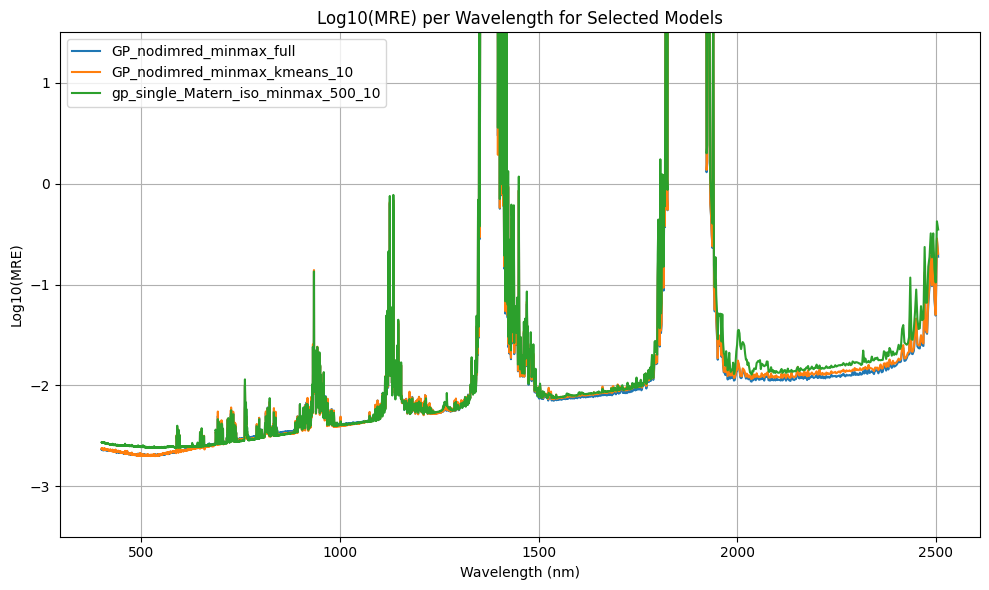

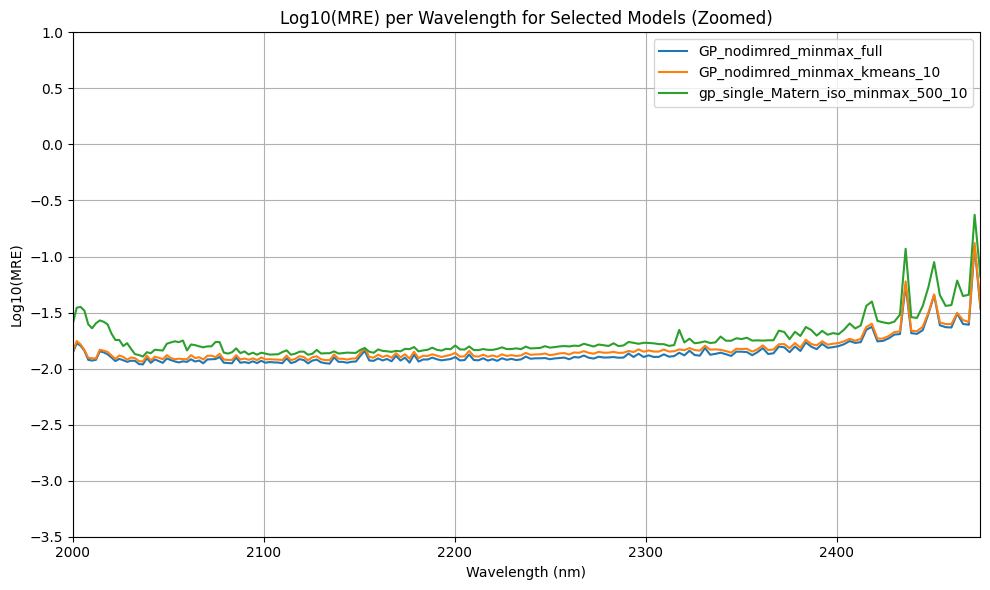

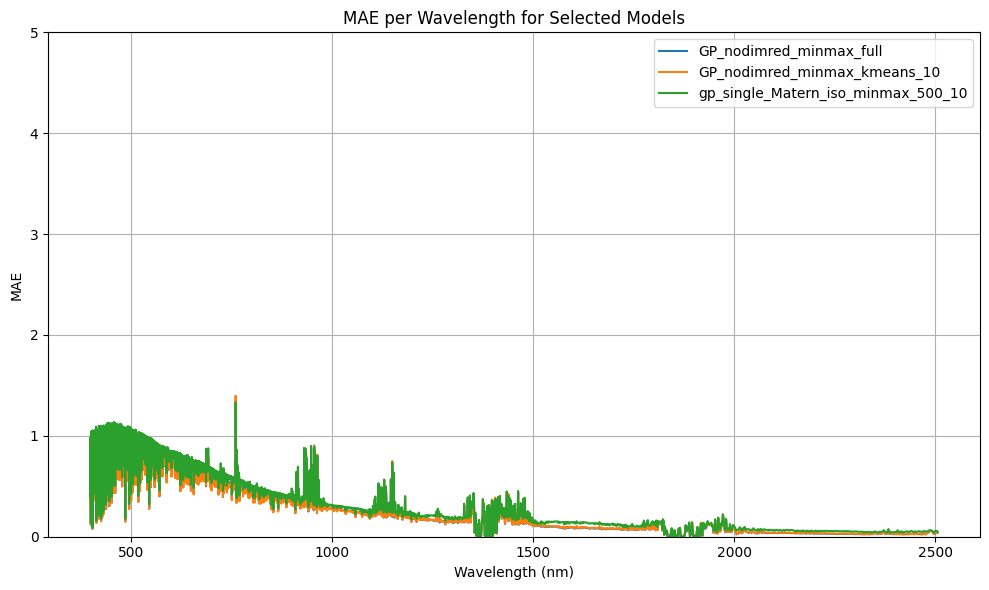

In [19]:
selected_models = [
    # "gp_single_Matern_minmax_500",
    # "gp_single_Matern_minmax_2000",
    # "gp_sel_combined_emulator_standard_500_full_search",
    "GP_nodimred_minmax_full",
    "GP_nodimred_minmax_kmeans_10",
    "gp_single_Matern_iso_minmax_500_10",
    # "GP_nodimred_minmax_windowed_median",
    # "nn_EmulatorSet1_multi_standard_10000",
    # "nn_EmulatorSet2_single_minmax_10000",
    # "nn_EmulatorSet3_single_standard_10000",
    # "nn_EmulatorSet4_multi_standard_10000",
    # "nn_EmulatorSet5_multi_standard_500",
    # "nn_EmulatorSet5_multi_standard_2000",
    # "nn_EmulatorSet5_multi_standard_10000",
    # "nn_EmulatorSet6_multi_standard_10000",
    # "nn_EmulatorSet5_multi_standard_500",
    # "nn_EmulatorSet6_multi_standard_500",

]

mre_to_plot = {
    name: all_mre[name]
    for name in selected_models
    if name in all_mre
}

mae_to_plot = {
    name: all_mae[name]
    for name in selected_models
    if name in all_mae
}

# FOR ZOOMED PLOTS USE 750-850nm RANGE

utils.show_multiple_experiments_errors(mre_to_plot, wavelengths, ylims=[-3.5, 1.5], ylabel="Log10(MRE)", title="Log10(MRE) per Wavelength for Selected Models")
utils.show_multiple_experiments_errors(mre_to_plot, wavelengths, xlims=[2000, 2475], ylims=[-3.5, 1], ylabel="Log10(MRE)", title="Log10(MRE) per Wavelength for Selected Models (Zoomed)")
utils.show_multiple_experiments_errors(mae_to_plot, wavelengths, ylims=[0, 5], ylabel="MAE", title="MAE per Wavelength for Selected Models")